In [1]:
import json
import pandas as pd

with open("../../dataset/train_sentiment.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df1 = pd.DataFrame(data)

# print(df.head())

In [2]:
df2 = pd.read_csv('../../dataset/review_shopping.csv', sep='\t', names=['text', 'sentiment'], header=None)
df2['sentiment'] = df2['sentiment'].replace({
    'neg': 'negative',
    'pos': 'positive'
})

<Axes: xlabel='sentiment'>

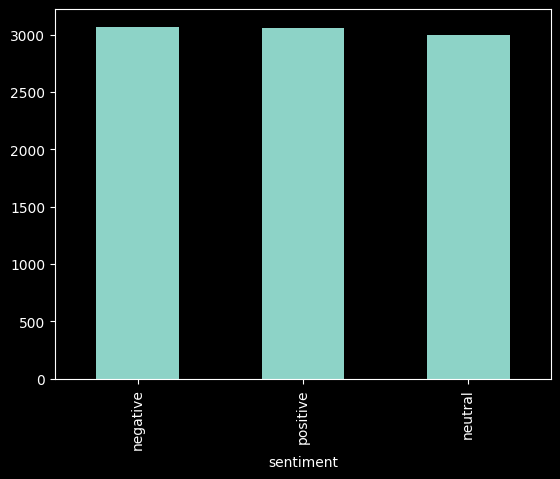

In [3]:
df = pd.concat([df1, df2], ignore_index=True)
df['sentiment'].value_counts().plot.bar()

In [4]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [5]:
from models.preprocess import clean_text
text = df['text']
sentiment = df['sentiment']

text = df["text"].apply(clean_text)
text.head()

0                มาตามนัด เขตพญาไท กรุงเทพมหานคร ณเฟ้ย
1    แยกราชเทวีจะรื้อน้ำพุกี่โมง ขอใช้พื้นที่ทวงคืน...
2    สดไอซ์ รักชนก แถลงข่าวการประมูลคลื่นความถี่ กส...
3    เขตหนองจอก ติดตามการดำเนินงานโครงการกองทุนหลัก...
4    ไทวัสดุ ส่งช่างมือ วีฟิกซ์ ร่วมฟื้นฟู ปรับภูมิ...
Name: text, dtype: object

In [10]:
from sklearn.model_selection import train_test_split

text_train, text_val, sentiment_train, sentiment_val = train_test_split(
    text, sentiment, test_size=0.2, random_state=42
)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from models.preprocess import tokenizer

vectorizer = TfidfVectorizer(
    tokenizer=tokenizer,
    ngram_range=(1,2),
)

text_train_tfidf = vectorizer.fit_transform(text_train)
text_val_tfidf = vectorizer.transform(text_val)

c:\Users\Jin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.5)

model.fit(text_train_tfidf, sentiment_train)

LinearSVC()

In [15]:
from sklearn.metrics import accuracy_score, classification_report # type: ignore

y_pred = model.predict(text_val_tfidf)

print("Accuracy:", accuracy_score(sentiment_val, y_pred))
print(classification_report(sentiment_val, y_pred))

Accuracy: 0.7957283680175247
              precision    recall  f1-score   support

    negative       0.84      0.84      0.84       610
     neutral       0.76      0.69      0.73       624
    positive       0.79      0.86      0.82       592

    accuracy                           0.80      1826
   macro avg       0.80      0.80      0.80      1826
weighted avg       0.79      0.80      0.79      1826



In [53]:
import pickle

with open("../../models/SVM/sentiment_model.pkl", "wb") as f:
    pickle.dump((vectorizer, model), f)

In [39]:
import pickle

with open("sentiment_model.pkl", "rb") as f:
    vectorizer, model = pickle.load(f)

test_text = "ไป ตาย ไป"

vec = vectorizer.transform([test_text])
prediction = model.predict(vec)

print("Prediction:", prediction[0])

Prediction: negative
